In [4]:
! pip install scikit-optimize
import numpy as np
import pandas as pd
from skopt.sampler import Sobol
from skopt.space import Real
import pandas as pd
import math

In [5]:
import numpy as np
import pandas as pd
from skopt.space import Real
from skopt.sampler import Sobol

# Set number of samples and seed
n_samples = 10000
np.random.seed(42)

# Define parameter space (omit d1 here)
space = [
    # first layer
    Real(5, 20, name='HBO1'),
    Real(2.5, 12.5, name='HHB1'),
    Real(0, 1.5, name='CCO1'),

    # second layer
    Real(25, 55, name='HBO2'),
    Real(15, 35, name='HHB2'),
    Real(2, 12, name='CCO2'),

    # other properties (excluding d1)
    Real(0.9, 6.9, name='a1'),
    Real(1.1, 4.2, name='a2'),
    Real(0.1, 2.5, name='b1'),
    Real(0.3, 3.3, name='b2'),
]

# Initialize Sobol sampler
sobol = Sobol()

# Generate samples
samples = sobol.generate(space, n_samples)

# Convert to DataFrame
cols_wo_d1 = [dim.name for dim in space]
df_sobol = pd.DataFrame(samples, columns=cols_wo_d1)

# Insert constant d1=12 after CCO2 (index 6 because there are 6 cols before it)
df_sobol.insert(loc=6, column='d1', value=13)

# Add ID
df_sobol['ID'] = np.arange(1, len(df_sobol) + 1)

# Preview
print(df_sobol.head())

# Export to CSV
df_sobol.to_csv("satge1.csv", index=False)


C:\Users\Haiya\anaconda3\Lib\site-packages\skopt\sampler\sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+10000=10000. 
  warnings.warn(


        HBO1       HHB1      CCO1       HBO2       HHB2       CCO2  d1  \
0  10.618102  12.007143  1.097991  42.959755  18.120373   3.559945  13   
1  18.118102   7.007143  0.347991  27.959755  28.120373   8.559945  13   
2   6.868102   4.507143  0.722991  50.459755  33.120373   6.059945  13   
3  14.368102   9.507143  1.472991  35.459755  23.120373  11.059945  13   
4  16.243102   5.757143  0.535491  46.709755  15.620373   2.309945  13   

         a1        a2        b1        b2  ID  
0  1.248502  3.785146  1.542676  2.424218   1  
1  4.248502  2.235146  0.342676  0.924218   2  
2  5.748502  1.460146  2.142676  1.674218   3  
3  2.748502  3.010146  0.942676  3.174218   4  
4  1.998502  2.622646  1.842676  2.049218   5  


In [6]:
# Load or use existing df_sobol
n_parts = 20
total_rows = len(df_sobol)
rows_per_part = total_rows // n_parts

for i in range(n_parts):
    start = i * rows_per_part
    end = (i + 1) * rows_per_part if i < n_parts - 1 else total_rows
    part_df = df_sobol.iloc[start:end]
    part_df.to_csv(f"stage1_part_{i+1}.csv", index=False)
    print(f"Saved rows {start} to {end-1} → stage1_part_{i+1}.csv")

Saved rows 0 to 499 → stage1_part_1.csv
Saved rows 500 to 999 → stage1_part_2.csv
Saved rows 1000 to 1499 → stage1_part_3.csv
Saved rows 1500 to 1999 → stage1_part_4.csv
Saved rows 2000 to 2499 → stage1_part_5.csv
Saved rows 2500 to 2999 → stage1_part_6.csv
Saved rows 3000 to 3499 → stage1_part_7.csv
Saved rows 3500 to 3999 → stage1_part_8.csv
Saved rows 4000 to 4499 → stage1_part_9.csv
Saved rows 4500 to 4999 → stage1_part_10.csv
Saved rows 5000 to 5499 → stage1_part_11.csv
Saved rows 5500 to 5999 → stage1_part_12.csv
Saved rows 6000 to 6499 → stage1_part_13.csv
Saved rows 6500 to 6999 → stage1_part_14.csv
Saved rows 7000 to 7499 → stage1_part_15.csv
Saved rows 7500 to 7999 → stage1_part_16.csv
Saved rows 8000 to 8499 → stage1_part_17.csv
Saved rows 8500 to 8999 → stage1_part_18.csv
Saved rows 9000 to 9499 → stage1_part_19.csv
Saved rows 9500 to 9999 → stage1_part_20.csv


### Plottings 

In [9]:
df_sobol

,HBO1,HHB1,CCO1,HBO2,HHB2,CCO2,d1,a1,a2,b1,b2,ID
0,10.618102,12.007143,1.097991,42.959755,18.120373,3.559945,13,1.248502,3.785146,1.542676,2.424218,1
1,18.118102,7.007143,0.347991,27.959755,28.120373,8.559945,13,4.248502,2.235146,0.342676,0.924218,2
2,6.868102,4.507143,0.722991,50.459755,33.120373,6.059945,13,5.748502,1.460146,2.142676,1.674218,3
3,14.368102,9.507143,1.472991,35.459755,23.120373,11.059945,13,2.748502,3.010146,0.942676,3.174218,4
4,16.243102,5.757143,0.535491,46.709755,15.620373,2.309945,13,1.998502,2.622646,1.842676,2.049218,5
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,17.249266,7.471621,1.061278,25.837562,25.086926,4.126962,13,2.102872,1.824752,2.008936,2.780358,9996
9996,15.374266,3.721621,1.248778,29.587562,17.586926,5.376962,13,2.852872,1.437252,1.108936,1.655358,9997
9997,7.874266,8.721621,0.498778,44.587562,27.586926,10.376962,13,5.852872,2.987252,2.308936,3.155358,9998
9998,19.124266,6.221621,0.873778,37.087562,22.586926,7.876962,13,4.352872,2.212252,0.508936,0.905358,9999


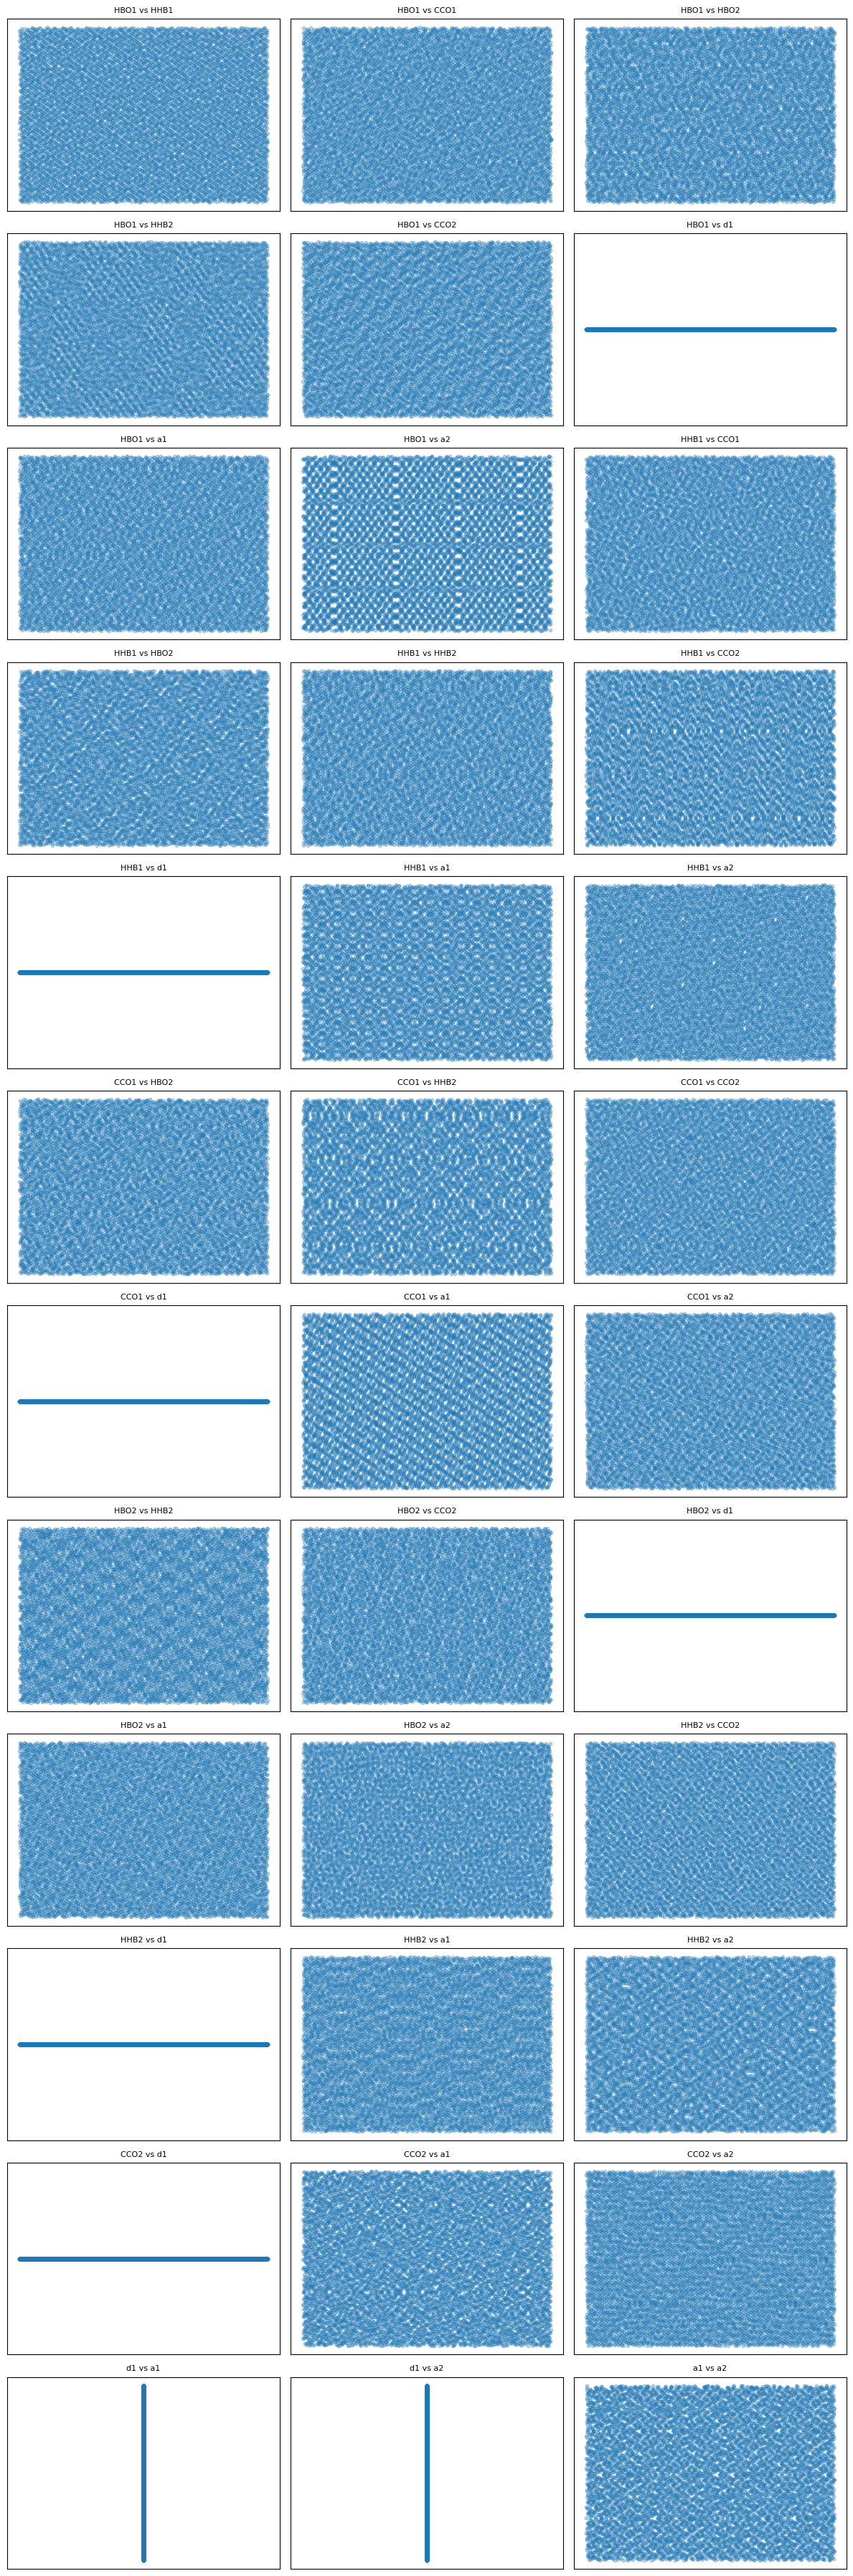

In [10]:
import matplotlib.pyplot as plt
import itertools

# Get first 9 parameter columns (exclude ID if present)
cols = df_sobol.columns[:9]
pairs = list(itertools.combinations(cols, 2))  # 36 combinations

fig, axs = plt.subplots(nrows=12, ncols=3, figsize=(12, 36))
axs = axs.flatten()

for i, (x_col, y_col) in enumerate(pairs):
    ax = axs[i]
    ax.scatter(df_sobol[x_col], df_sobol[y_col], alpha=0.3, s=10)
    ax.set_title(f'{x_col} vs {y_col}', fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

# Turn off unused axes (if any)
for j in range(i + 1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()
